In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("my_pcos_journey.csv", encoding="latin1")
df.head()

,Year,Month,Height_cm,Weight_lb,BMI,Workout_Days,Workout_Type,Calories_Intake,Sleep_Hours,Mood_Score,Fitness_Level,Menstrual_Cycle,PCOS_Score,Data_Source
0,2021,January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manual Log
1,2021,February,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manual Log
2,2021,March,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manual Log
3,2021,April,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manual Log
4,2021,May,165.0,170.0,28.3,5.0,Crossfit,1412.0,7.6,6.0,Beginner,Irregular,1.0,Manual Log


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             66 non-null     int64  
 1   Month            66 non-null     str    
 2   Height_cm        62 non-null     float64
 3   Weight_lb        62 non-null     float64
 4   BMI              61 non-null     float64
 5   Workout_Days     62 non-null     float64
 6   Workout_Type     43 non-null     str    
 7   Calories_Intake  60 non-null     float64
 8   Sleep_Hours      60 non-null     float64
 9   Mood_Score       60 non-null     float64
 10  Fitness_Level    62 non-null     str    
 11  Menstrual_Cycle  62 non-null     str    
 12  PCOS_Score       61 non-null     float64
 13  Data_Source      66 non-null     str    
dtypes: float64(8), int64(1), str(5)
memory usage: 10.3 KB


In [4]:
# Check null counts
print(df.isnull().sum())

Year                0
Month               0
Height_cm           4
Weight_lb           4
BMI                 5
Workout_Days        4
Workout_Type       23
Calories_Intake     6
Sleep_Hours         6
Mood_Score          6
Fitness_Level       4
Menstrual_Cycle     4
PCOS_Score          5
Data_Source         0
dtype: int64


In [5]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [6]:
#Drop the unessary column
df = df.drop(columns=['Data_Source'])
print(df.shape)

(66, 13)


In [7]:
#Deleting First 4 empty rows
df = df[df['Weight_lb'].notna()]
print(df.shape)

(62, 13)


In [8]:
#remove duplicate row
df = df.drop_duplicates()
print(df.shape)

(61, 13)


In [9]:
#BMI calculation for missing null values and correct imput
df['BMI'] = ((df['Weight_lb'] * 0.453592) / ((df['Height_cm'] / 100) ** 2)).round(1)
print(df['BMI'].isnull().sum())

0


In [10]:
#Filling data in workout type column
df['Workout_Type'] = df['Workout_Type'].fillna('None / Walking')
print(df['Workout_Type'].isnull().sum())

0


In [11]:
#filling the null values with median
cols = ['Sleep_Hours', 'Mood_Score', 'Calories_Intake', 'PCOS_Score']

for col in cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val}")

Sleep_Hours: filled with median = 6.9
Mood_Score: filled with median = 6.0
Calories_Intake: filled with median = 1674.0
PCOS_Score: filled with median = 4.0


In [12]:
print(df.isnull().sum())

Year               0
Month              0
Height_cm          0
Weight_lb          0
BMI                0
Workout_Days       0
Workout_Type       0
Calories_Intake    0
Sleep_Hours        0
Mood_Score         0
Fitness_Level      0
Menstrual_Cycle    0
PCOS_Score         0
dtype: int64


In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 61 entries, 4 to 65
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             61 non-null     int64  
 1   Month            61 non-null     str    
 2   Height_cm        61 non-null     float64
 3   Weight_lb        61 non-null     float64
 4   BMI              61 non-null     float64
 5   Workout_Days     61 non-null     float64
 6   Workout_Type     61 non-null     str    
 7   Calories_Intake  61 non-null     float64
 8   Sleep_Hours      61 non-null     float64
 9   Mood_Score       61 non-null     float64
 10  Fitness_Level    61 non-null     str    
 11  Menstrual_Cycle  61 non-null     str    
 12  PCOS_Score       61 non-null     float64
dtypes: float64(8), int64(1), str(4)
memory usage: 9.2 KB


In [14]:
df.head()

,Year,Month,Height_cm,Weight_lb,BMI,Workout_Days,Workout_Type,Calories_Intake,Sleep_Hours,Mood_Score,Fitness_Level,Menstrual_Cycle,PCOS_Score
4,2021,May,165.0,170.0,28.3,5.0,Crossfit,1412.0,7.6,6.0,Beginner,Irregular,1.0
5,2021,June,165.0,175.0,29.2,5.0,Crossfit,1679.0,6.9,8.0,Beginner,Regular,1.0
6,2021,July,165.0,180.0,30.0,3.0,Crossfit,1519.0,7.3,5.0,Beginner,Irregular,3.0
7,2021,August,165.0,178.0,29.7,5.0,Crossfit + Functional,1679.0,7.1,8.0,Beginner,Irregular,1.0
8,2021,September,165.0,176.5,29.4,3.0,Crossfit + Functional,1616.0,7.0,6.0,Beginner,Irregular,2.0


In [15]:
df = df.reset_index(drop=True)
df.head()

,Year,Month,Height_cm,Weight_lb,BMI,Workout_Days,Workout_Type,Calories_Intake,Sleep_Hours,Mood_Score,Fitness_Level,Menstrual_Cycle,PCOS_Score
0,2021,May,165.0,170.0,28.3,5.0,Crossfit,1412.0,7.6,6.0,Beginner,Irregular,1.0
1,2021,June,165.0,175.0,29.2,5.0,Crossfit,1679.0,6.9,8.0,Beginner,Regular,1.0
2,2021,July,165.0,180.0,30.0,3.0,Crossfit,1519.0,7.3,5.0,Beginner,Irregular,3.0
3,2021,August,165.0,178.0,29.7,5.0,Crossfit + Functional,1679.0,7.1,8.0,Beginner,Irregular,1.0
4,2021,September,165.0,176.5,29.4,3.0,Crossfit + Functional,1616.0,7.0,6.0,Beginner,Irregular,2.0


In [16]:
#double checking
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Shape: (61, 13)
Nulls: 0
Duplicates: 0


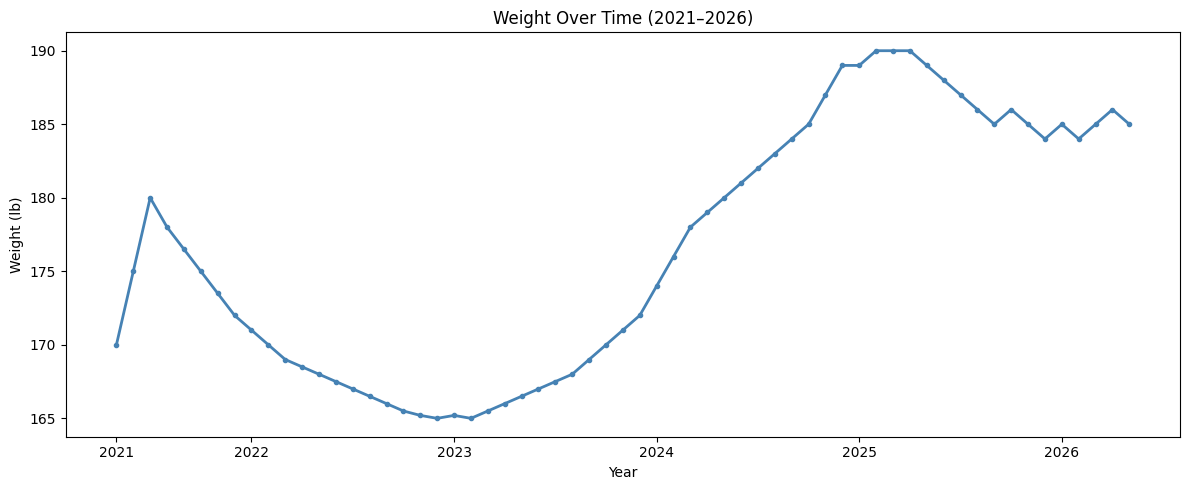

In [17]:
# Checking Correlation

plt.figure(figsize=(12, 5))

plt.plot(df.index, df['Weight_lb'], color='steelblue', linewidth=2, marker='o', markersize=3)

plt.title('Weight Over Time (2021–2026)')
plt.xlabel('Year')
plt.ylabel('Weight (lb)')

year_ticks = df.groupby('Year').apply(lambda x: x.index[0])
plt.xticks(ticks=year_ticks.values, labels=year_ticks.index)

plt.tight_layout()
plt.show()

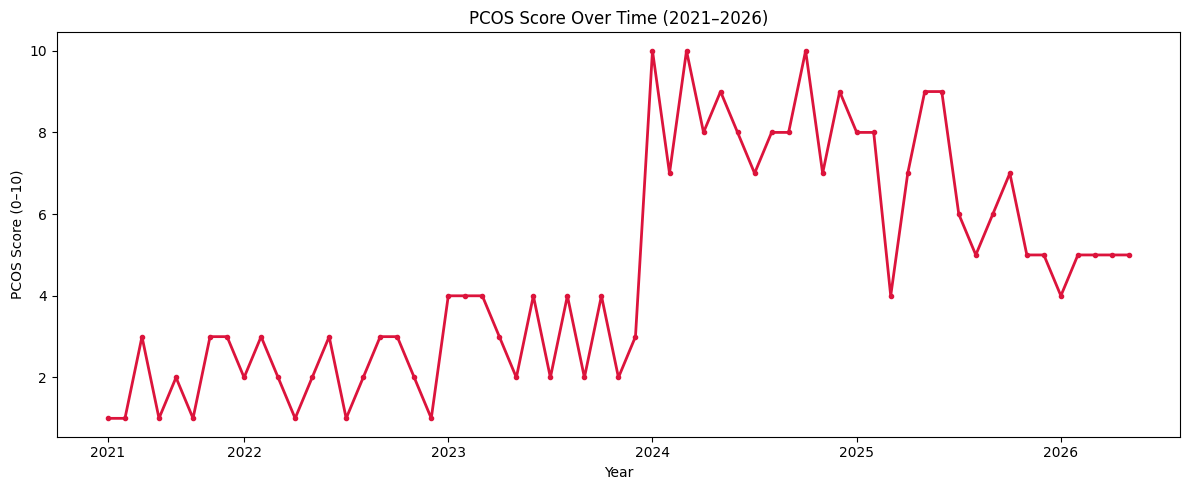

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df['PCOS_Score'], color='crimson', linewidth=2, marker='o', markersize=3)

plt.title('PCOS Score Over Time (2021–2026)')
plt.xlabel('Year')
plt.ylabel('PCOS Score (0–10)')

# Get the index position where each year starts
year_ticks = df.groupby('Year').apply(lambda x: x.index[0])
plt.xticks(ticks=year_ticks.values, labels=year_ticks.index)

plt.tight_layout()
plt.show()

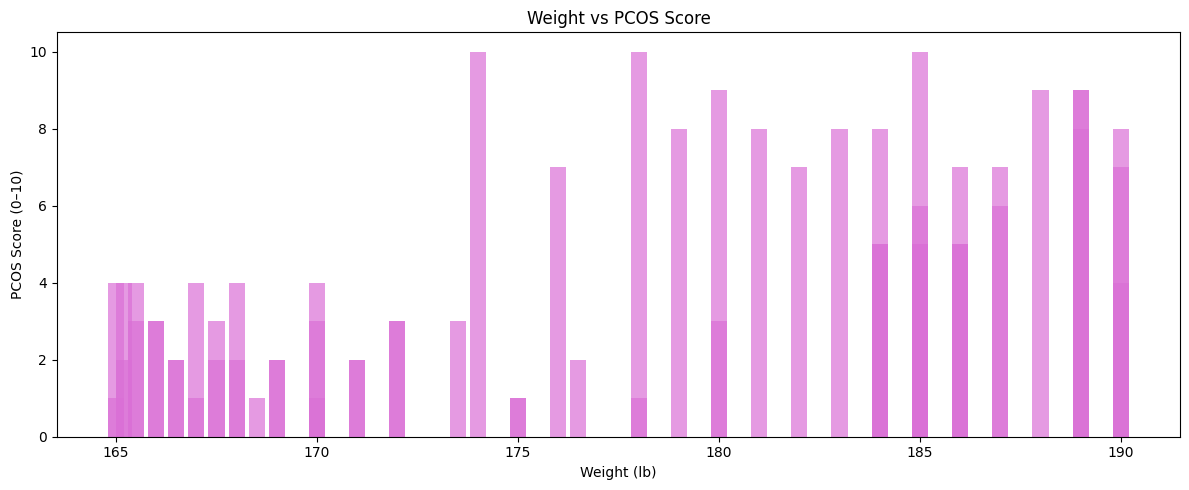

In [19]:
#Correlation between weight and PCOS score
plt.figure(figsize=(12, 5))

plt.bar(df['Weight_lb'], df['PCOS_Score'], color='orchid', alpha=0.7, width=0.4)

plt.title('Weight vs PCOS Score')
plt.xlabel('Weight (lb)')
plt.ylabel('PCOS Score (0–10)')

plt.tight_layout()
plt.show()

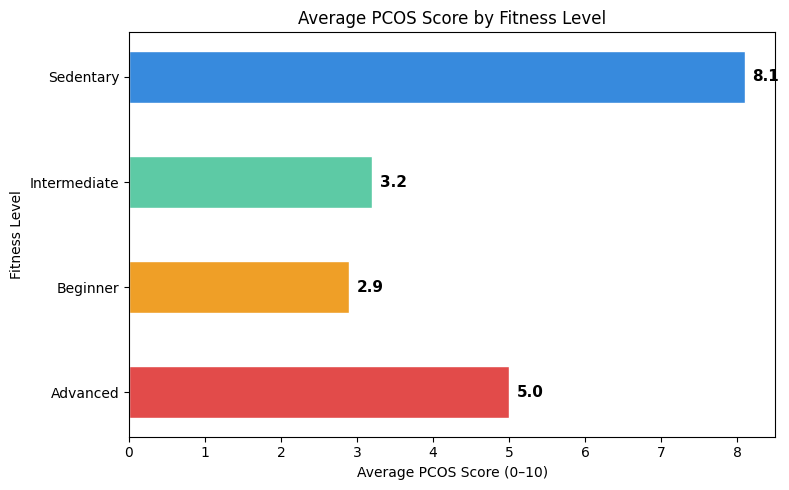

In [20]:
plt.figure(figsize=(8, 5))

# Calculate average PCOS score per fitness level
fitness_pcos = df.groupby('Fitness_Level')['PCOS_Score'].mean().round(1)

colors = ['#E24B4A', '#EF9F27', '#5DCAA5', '#378ADD']

plt.barh(fitness_pcos.index, fitness_pcos.values, color=colors, edgecolor='white', height=0.5)

plt.title('Average PCOS Score by Fitness Level')
plt.xlabel('Average PCOS Score (0–10)')
plt.ylabel('Fitness Level')

# Add value labels at the end of each bar
for i, val in enumerate(fitness_pcos.values):
    plt.text(val + 0.1, i, str(val), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

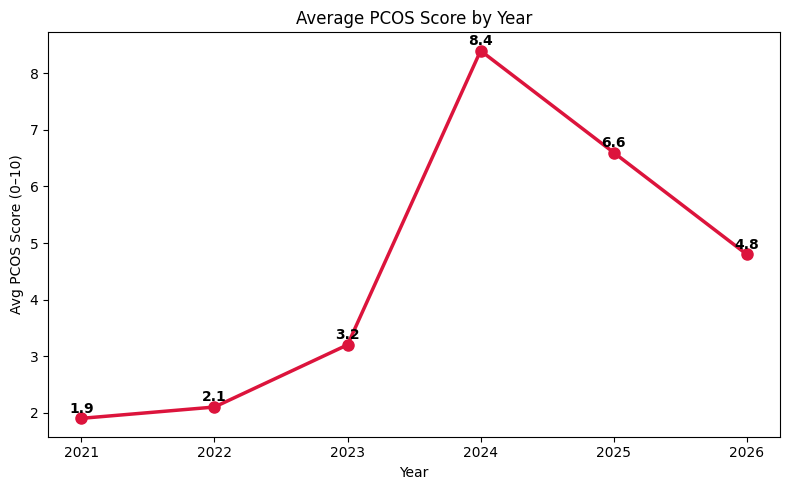

In [21]:
# Average PCOS Score by year — shows which period was worst
pcos_by_year = df.groupby('Year')['PCOS_Score'].mean().round(1)

plt.figure(figsize=(8, 5))

plt.plot(pcos_by_year.index, pcos_by_year.values, color='crimson', 
         linewidth=2.5, marker='o', markersize=8)

# Add value labels
for x, y in zip(pcos_by_year.index, pcos_by_year.values):
    plt.text(x, y + 0.1, str(y), ha='center', fontsize=10, fontweight='bold')

plt.title('Average PCOS Score by Year')
plt.xlabel('Year')
plt.ylabel('Avg PCOS Score (0–10)')
plt.xticks(pcos_by_year.index)

plt.tight_layout()
plt.show()

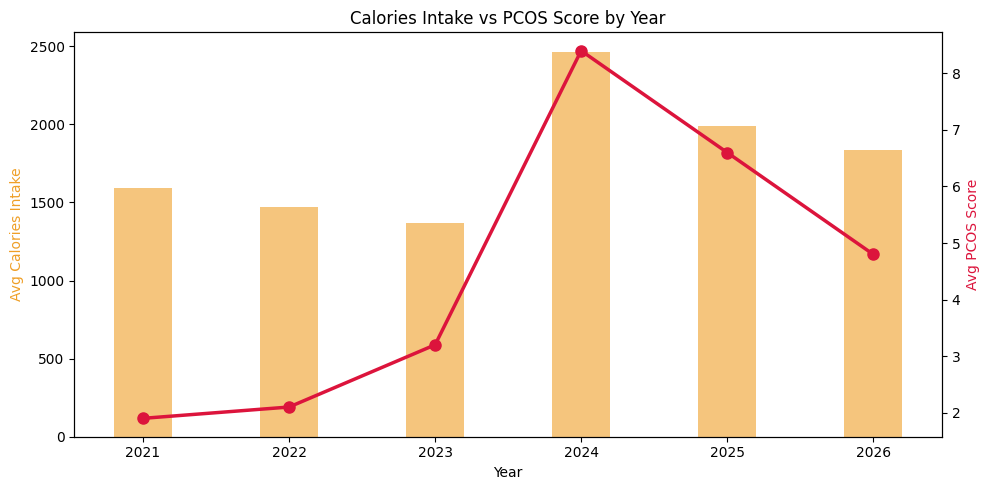

In [22]:
# Average Calories and PCOS Score by year
calories_by_year = df.groupby('Year')['Calories_Intake'].mean().round(0)
pcos_by_year = df.groupby('Year')['PCOS_Score'].mean().round(1)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Calories bar
ax1.bar(calories_by_year.index, calories_by_year.values, color='#EF9F27', alpha=0.6, width=0.4, label='Calories Intake')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Calories Intake', color='#EF9F27')

# PCOS line on same chart
ax2 = ax1.twinx()
ax2.plot(pcos_by_year.index, pcos_by_year.values, color='crimson', linewidth=2.5, marker='o', markersize=8, label='PCOS Score')
ax2.set_ylabel('Avg PCOS Score', color='crimson')

plt.title('Calories Intake vs PCOS Score by Year')
fig.tight_layout()
plt.show()

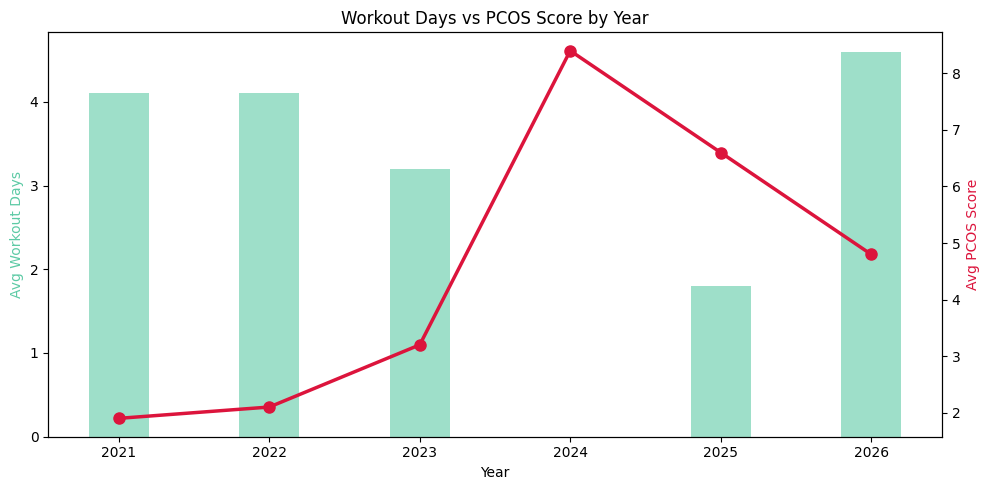

In [23]:
# Average Workout Days and PCOS Score by year
workout_by_year = df.groupby('Year')['Workout_Days'].mean().round(1)
pcos_by_year = df.groupby('Year')['PCOS_Score'].mean().round(1)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Workout bars
ax1.bar(workout_by_year.index, workout_by_year.values, color='#5DCAA5', alpha=0.6, width=0.4, label='Workout Days')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Workout Days', color='#5DCAA5')

# PCOS line
ax2 = ax1.twinx()
ax2.plot(pcos_by_year.index, pcos_by_year.values, color='crimson', linewidth=2.5, marker='o', markersize=8, label='PCOS Score')
ax2.set_ylabel('Avg PCOS Score', color='crimson')

plt.title('Workout Days vs PCOS Score by Year')
fig.tight_layout()
plt.show()

In [24]:
# checking best and worst months
df['Month_Year'] = df['Month'] + ' ' + df['Year'].astype(str)

# Top 3 best months = lowest PCOS Score
best = df.nsmallest(3, 'PCOS_Score')[['Month_Year', 'PCOS_Score', 'Weight_lb', 'Mood_Score', 'Workout_Days']]

# Top 3 worst months = highest PCOS Score
worst = df.nlargest(3, 'PCOS_Score')[['Month_Year', 'PCOS_Score', 'Weight_lb', 'Mood_Score', 'Workout_Days']]

print("🌸 TOP 3 BEST MONTHS:")
print(best.to_string(index=False))

print()

print("⚠️ TOP 3 WORST MONTHS:")
print(worst.to_string(index=False))

🌸 TOP 3 BEST MONTHS:
 Month_Year  PCOS_Score  Weight_lb  Mood_Score  Workout_Days
   May 2021         1.0      170.0         6.0           5.0
  June 2021         1.0      175.0         8.0           5.0
August 2021         1.0      178.0         8.0           5.0

⚠️ TOP 3 WORST MONTHS:
  Month_Year  PCOS_Score  Weight_lb  Mood_Score  Workout_Days
January 2024        10.0      174.0         2.0           0.0
  March 2024        10.0      178.0         5.0           0.0
October 2024        10.0      185.0         3.0           0.0


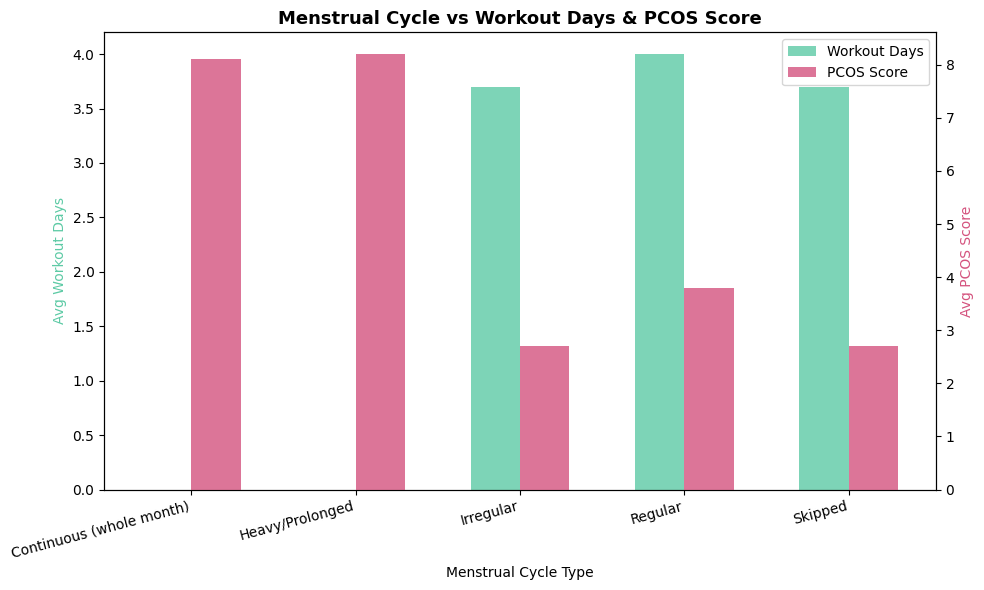

In [27]:
# Average Workout Days and PCOS Score by Menstrual Cycle type
menstrual_group = df.groupby('Menstrual_Cycle')[['Workout_Days', 'PCOS_Score']].mean().round(1)

x = range(len(menstrual_group.index))
width = 0.3

fig, ax1 = plt.subplots(figsize=(10, 6))

# Workout Days bars
ax1.bar([i - width/2 for i in x], menstrual_group['Workout_Days'], 
        width=width, color='#5DCAA5', alpha=0.8, label='Workout Days')
ax1.set_ylabel('Avg Workout Days', color='#5DCAA5')
ax1.set_xlabel('Menstrual Cycle Type')
ax1.set_xticks(x)
ax1.set_xticklabels(menstrual_group.index, rotation=15, ha='right')

# PCOS Score bars on second axis
ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], menstrual_group['PCOS_Score'], 
        width=width, color='#D4537E', alpha=0.8, label='PCOS Score')
ax2.set_ylabel('Avg PCOS Score', color='#D4537E')

ax1.set_title('Menstrual Cycle vs Workout Days & PCOS Score', fontsize=13, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

In [41]:
df.to_csv('pcos_cleaned.csv', index=False)
print("✅ Saved!")
print("Shape:", df.shape)

✅ Saved!
Shape: (61, 13)
